### 1.- Pesos en la funcion de correlacion

#### a)

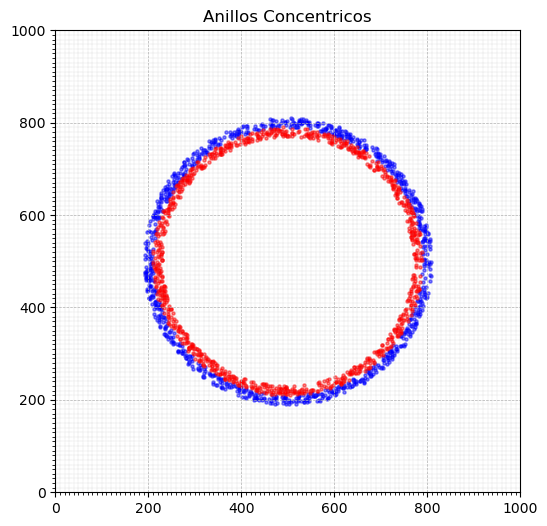

In [34]:
import sympy as owo
import numpy as uwu
import matplotlib as mlp
import matplotlib.pyplot as plt
from scipy import special
import math
import pandas as pd
import matplotlib.ticker as ticker
from mpl_toolkits.mplot3d import Axes3D

#=================================================================================
#Definicion de Funciones
#===================================================================================

def spawn_puntos(n, t):
    x = uwu.random.uniform(0, t, n)  # Genera números aleatorios de 0 a t en x
    y = uwu.random.uniform(0, t, n)  # Genera números aleatorios de 0 a t en y
    puntos2 = uwu.vstack((x, y)).T   # Ordena los datos en una matriz de n x 2
    return puntos2

def spawn_puntos_anillo(n, t, rm,rM,centro): #Distribucion de anillo
        #Centro debe ser un punto en el plano.
    
        angulos = uwu.random.uniform(0, 2*uwu.pi, n) #Genera angulos entre 0 a 2\pi
        radios = uwu.random.uniform(rm, rM, n)   # Generar radios de 0 a r, rm es el radio menor y rM el radio mayor del anillo
        x = radios * uwu.cos(angulos) #Transformacion de polares a cartesianas
        y = radios * uwu.sin(angulos)
        x += centro[0]  #Traslada el centro a las coordenadas de eleccion 
        y += centro[1]
        puntos = uwu.vstack((x, y)).T   #Ordena los datos en una matriz de n x 2
        
        return puntos


def Histo_distancias(dim_hist, num_p, p, bin_size): #Funcion que calcula el histograma
    Hist = uwu.zeros(dim_hist)
    for i in range(num_p):
        for j in range(i + 1, num_p):
            dist = uwu.sqrt((p[i, 0] - p[j, 0]) ** 2 + (p[i, 1] - p[j, 1]) ** 2)
            bin = int(dist / bin_size)  # Calcula a qué bin pertenece.
                
            if bin >= dim_hist:  #Envia a His[0] todas las distancias que esten fuera de los bins analizados.
                Hist[0] += 1  
            else:
                Hist[max(1, bin)] += 1  # Si bin=0, se registra en Hist[1], de otro modo en Hist[bin]
                    
    return Hist

def Histo_DR(dim_hist, num_pdatos,num_paleatorios, p_datos,p_aleatorios, bin_size): #Funcion que calcula DR
    Hist = uwu.zeros(dim_hist)
    for i in range(num_pdatos):
        for j in range(num_paleatorios):
            dist = uwu.sqrt((p_datos[i, 0] - p_aleatorios[j, 0]) ** 2 + (p_datos[i, 1] - p_aleatorios[j, 1]) ** 2)
            bin = int(dist / bin_size)  # Calcula a qué bin pertenece.
                
            if bin >= dim_hist:  #Envia a His[0] todas las distancias que esten fuera de los bins analizados.
                    Hist[0] += 1  
            else:
                Hist[max(1, bin)] += 1  # Si bin=0, se registra en Hist[1], de otro modo en Hist[bin]
                    
    return Hist

def Histo_distancias_pesado(dim_hist, num_p, p_pesado, bin_size): #Funcion que calcula el histograma
    Hist = uwu.zeros(dim_hist)
    posicion=p_pesado[:,:2]
    for i in range(num_p):
        for j in range(i + 1, num_p):
            dist = uwu.sqrt((posicion[i, 0] - posicion[j, 0]) ** 2 + (posicion[i, 1] - posicion[j, 1]) ** 2)
            bin = int(dist / bin_size)  # Calcula a qué bin pertenece.
                
            if bin >= dim_hist:  #Envia a His[0] todas las distancias que esten fuera de los bins analizados.
                Hist[0] += 1  
            else:
                Hist[max(1, bin)] += p_pesado[i,2]*p_pesado[j,2]  # Si bin=0, se registra en Hist[1], de otro modo en Hist[bin]
                    
    return Hist

def Histo_DR_pesado(dim_hist, num_pdatos,num_paleatorios, p_datos_pesado,p_aleatorios_pesado, bin_size): #Funcion que calcula DR
    Hist = uwu.zeros(dim_hist)
    posicion_dat= p_datos_pesado[:, :2]
    posicion_al= p_aleatorios_pesado[:, :2]
    for i in range(num_pdatos):
        for j in range(num_paleatorios):
            dist = uwu.sqrt((posicion_dat[i, 0] - posicion_al[j, 0]) ** 2 + (posicion_dat[i, 1] - posicion_al[j, 1]) ** 2)
            bin = int(dist / bin_size)  # Calcula a qué bin pertenece.
            
            if bin >= dim_hist:  #Envia a His[0] todas las distancias que esten fuera de los bins analizados.
                    Hist[0] += 1  
            else:
                Hist[max(1, bin)] += p_datos_pesado[i,2]*p_aleatorios_pesado[j,2]  # Si bin=0, se registra en Hist[1], de otro modo en Hist[bin]
                    
    return Hist

def LS(dim_hist, num_pa ,num_pu,  bin_size, Anillo_Unido ,puntos_aleatorios): #Calculo de LS Normal
    #Histo RR usual
    Histo_RR=Histo_distancias(dim_hist, num_pa, puntos_aleatorios, bin_size)
    l_RR=0
    for k in range(dim_hist): #Calcula el numero total de distancias calculadas (frecuencias).
        l_RR=l_RR+Histo_RR[k]

    Histo_RR_N=Histo_RR/l_RR #Histograma usual normalizado para puntos random 
    #Histograma DD

    Histo_PuntosDDAnillo= Histo_distancias(dim_hist, num_pu, Anillo_Unido, bin_size) 
    l_DDAnillo=0
    for k in range(dim_hist): #Calcula el numero total de distancias calculadas (frecuencias).
        l_DDAnillo=l_DDAnillo+Histo_PuntosDDAnillo[k]

    Histo_PuntosDDAnillo_N=Histo_PuntosDDAnillo/l_DDAnillo # Histograma DD usual normalizado 

#--------------------------------------------------------------------------------

#Histograma DR

    Histo_PuntosDRAnillo= Histo_DR(dim_hist, num_pu ,num_pa, Anillo_Unido ,puntos_aleatorios, bin_size) 
    l_DRAnillo=0
    for k in range(dim_hist): #Calcula el numero total de distancias calculadas (frecuencias).
        l_DRAnillo=l_DRAnillo+Histo_PuntosDRAnillo[k]

    Histo_PuntosDRAnillo_N=Histo_PuntosDRAnillo/l_DRAnillo # Histograma DD usual normalizado 



#----------------------------------------------------------------------------------

#Funcion de correlacion

    LS_Anillo=uwu.zeros(dim_hist)  #Guarda los datos de la funcion Peebles-Hausler 
    for i in range(1,dim_hist): #Calcula la funcion de Peebles-Hausler
        LS_Anillo[i]=1+Histo_PuntosDDAnillo_N[i]/Histo_RR_N[i]-2*Histo_PuntosDRAnillo_N[i]/Histo_RR_N[i]
    
    return LS_Anillo

def LS_Pesado(dim_hist, numpa_campo, nump_campo, bin_size, Campo_Anillo_Near, puntos_alcampo_pesado): #Calculo de LS_Pesado
    #Histo RR
    Histo_RRC_pesado=Histo_distancias_pesado(dim_hist, numpa_campo, puntos_alcampo_pesado, bin_size)
    l_RRC_p=0
    for k in range(dim_hist): #Calcula el numero total de distancias calculadas (frecuencias).
        l_RRC_p=l_RRC_p+Histo_RRC_pesado[k]

    Histo_RRC_pesado_N=Histo_RRC_pesado/l_RRC_p #Histograma pesado normalizado para puntos random

#Histograma DD

    Histo_PuntosDDCampo_Anillo= Histo_distancias_pesado(dim_hist, nump_campo, Campo_Anillo_Near, bin_size) 
    l_DDAnillo_p=0
    for k in range(dim_hist): #Calcula el numero total de distancias calculadas (frecuencias).
        l_DDAnillo_p=l_DDAnillo_p+Histo_PuntosDDCampo_Anillo[k]

    Histo_PuntosDDCampo_Anillo_N=Histo_PuntosDDCampo_Anillo/l_DDAnillo_p # Histograma DD usual normalizado
#Histograma DR

    Histo_PuntosDRCampo_Anillo= Histo_DR_pesado(dim_hist, nump_campo ,numpa_campo, Campo_Anillo_Near,puntos_alcampo_pesado, bin_size) 
    l_DRAnillo_p=0
    for k in range(dim_hist): #Calcula el numero total de distancias calculadas (frecuencias).
        l_DRAnillo_p=l_DRAnillo_p+Histo_PuntosDRCampo_Anillo[k]

    Histo_PuntosDRCampo_Anillo_N=Histo_PuntosDRCampo_Anillo/l_DRAnillo_p # Histograma DD usual normalizado 

#----------------------------------------------------------------------------------

#Funcion de correlacion

    LS_Campo_Anillo=uwu.zeros(dim_hist)  #Guarda los datos de la funcion Peebles-Hausler 
    for i in range(1,dim_hist): #Calcula la funcion de Peebles-Hausler
        LS_Campo_Anillo[i]=1+Histo_PuntosDDCampo_Anillo_N[i]/Histo_RRC_pesado_N[i]-2*Histo_PuntosDRCampo_Anillo_N[i]/Histo_RRC_pesado_N[i]
        
    return LS_Campo_Anillo

#============================================================================================================
#INICIO
#===========================================================================================================

#Propiedades de los bines 

bin_size = 3  # Tamaño del Bin
dim_hist = 300  # Número de Bins: en realidad el numero es dim_hist-1, ya que, Hist[0] guarda todos los valores fuera de los rangos que estamos considerando.
tam=1000   #Tamaño del grafico

#Propiedades generales de los anillos 

centro=(500, 500) #Centro donde se generan los puntos del disco 
L=1000 #Tamaño de la caja
num_p = 1000  # Cantidad de puntos anillos
num_pa= 2000 # Numero de puntos aleatorios

# Caracteristicas del anillo mayor
r_m_azul=290 #Radio menor
r_M_azul=310 #Radio mayor


#Caracteristicas del anillo menor
r_m_rojo=270 #Radio menor
r_M_rojo=290 #Radio mayor


#Anillos
Anillo_G= spawn_puntos_anillo(num_p, tam,r_m_azul,r_M_azul,centro) 
Anillo_C= spawn_puntos_anillo(num_p, tam,r_m_rojo,r_M_rojo,centro)

Anillo_Unido=uwu.vstack((Anillo_G,Anillo_C)) #Anillo total

#Anillos y distribucion aleatoria pesada
peso_G= uwu.full((num_p, 1), 0.5) #Peso del anillo grande
peso_C= uwu.full((num_p,1), 2) #Peso del anillo chico
Anillo_G_pesado=uwu.hstack((Anillo_G, peso_G)) #Anillo grande con peso 
Anillo_C_pesado=uwu.hstack((Anillo_C,peso_C)) #Anillo chico con peso

Anillo_Unido_Pesado=uwu.vstack((Anillo_G_pesado,Anillo_C_pesado)) #Anillo total pesado

#Distribucion aleatoria

puntos_aleatorios=spawn_puntos(num_pa, tam) #Generacion de puntos aleatorios
peso_aleatorio=uwu.full((num_pa,1),1) #Pesos de los puntos aleatorios igualados a 1
puntos_aleatorios_pesado=uwu.hstack((puntos_aleatorios,peso_aleatorio)) #Puntos aleatorios pesados

num_pu=2*num_p


plt.figure(figsize=(6,6))
plt.scatter(Anillo_G[:,0], Anillo_G[:,1], alpha=0.5, s=5, color='blue') #Toma los valores en x e y en el spawn de puntos y los grafica
plt.scatter(Anillo_C[:,0], Anillo_C[:,1], alpha=0.5, s=5, color='red') #Toma los valores en x e y en el spawn de puntos y los grafica
plt.xlim(0, tam) #Tam define el tamaño del grafico 
plt.ylim(0, tam)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.xticks(uwu.arange(0, tam+1, 200)) # Ejes cada 200 unidades
plt.yticks(uwu.arange(0, tam+1, 200))
ax = plt.gca()
ax.set_xticks(uwu.arange(0, tam+1, 10), minor=True) # Cuadriculado de 10x10
ax.set_yticks(uwu.arange(0, tam+1, 10), minor=True)
ax.grid(True, which='minor', linestyle=':', linewidth=0.3)
plt.title("Anillos Concentricos")
plt.show()


#### c)

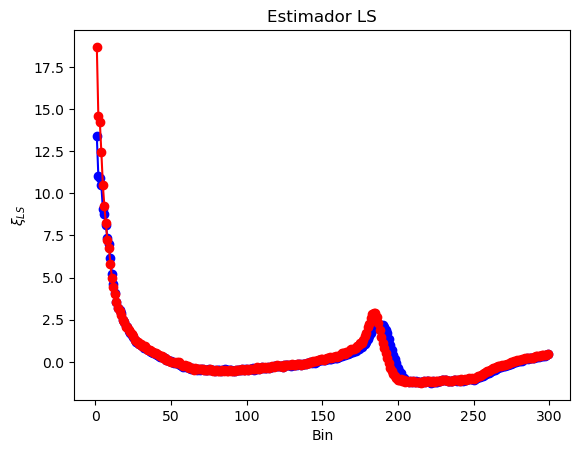

In [36]:
#==============================================================
#Funciones de correlacion 
#===============================================================

LS_Anillo=LS(dim_hist, num_pa ,num_pu,  bin_size, Anillo_Unido ,puntos_aleatorios)

LS_Anillo_pesado=LS_Pesado(dim_hist, num_pa, num_pu, bin_size, Anillo_Unido_Pesado, puntos_aleatorios_pesado)


#=================================================================
# Grafica de las funciones
#==================================================================

plt.plot(range(1, dim_hist), LS_Anillo[1:], marker='o', color='b',linestyle="solid", label='Usual')  #Grafica los datos desde His[1] hasta Hist[dim_hist-1] respecto al bin correspondiente.
plt.plot(range(1, dim_hist), LS_Anillo_pesado[1:], marker='o', color='r',linestyle="solid", label='Pesada')
plt.xlabel("Bin")
plt.ylabel(r"$\xi_{LS}$")
plt.title("Estimador LS")
plt.show()


### 2.- De partículas a una malla. Usa la rutina scipy.interpolate.griddata. 

### a)

<Figure size 800x800 with 0 Axes>

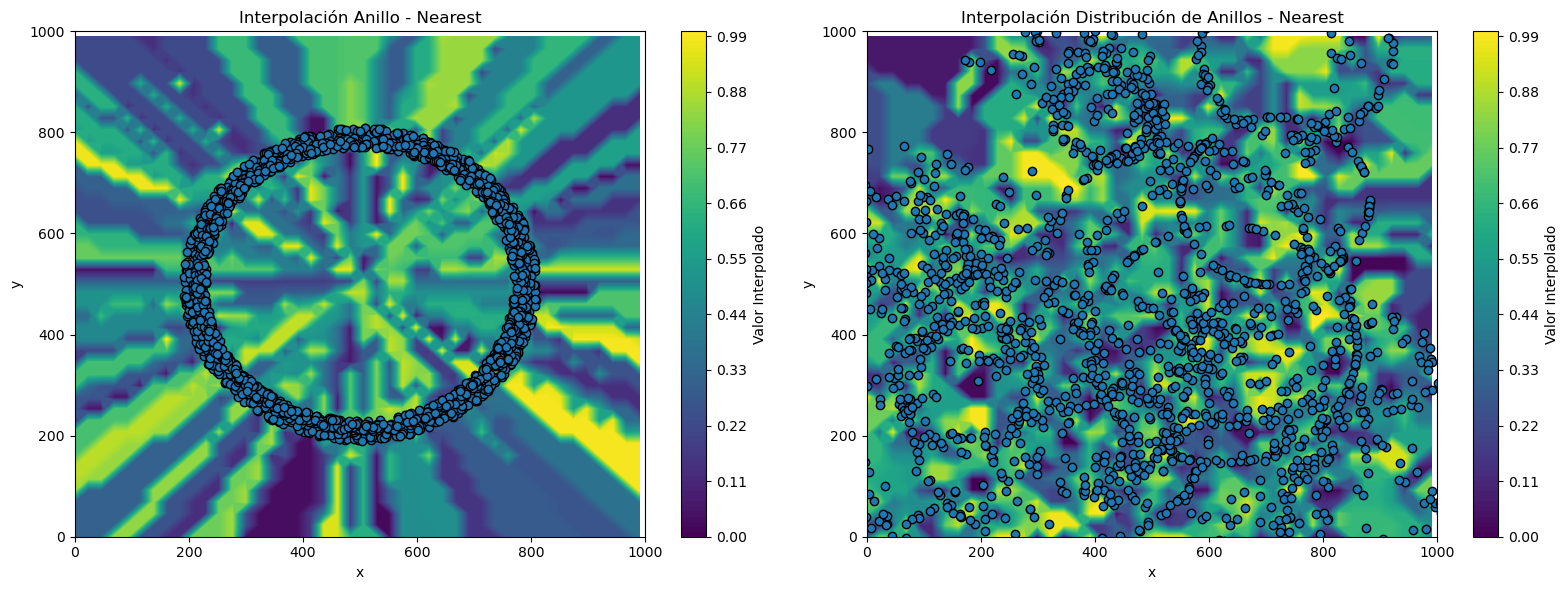

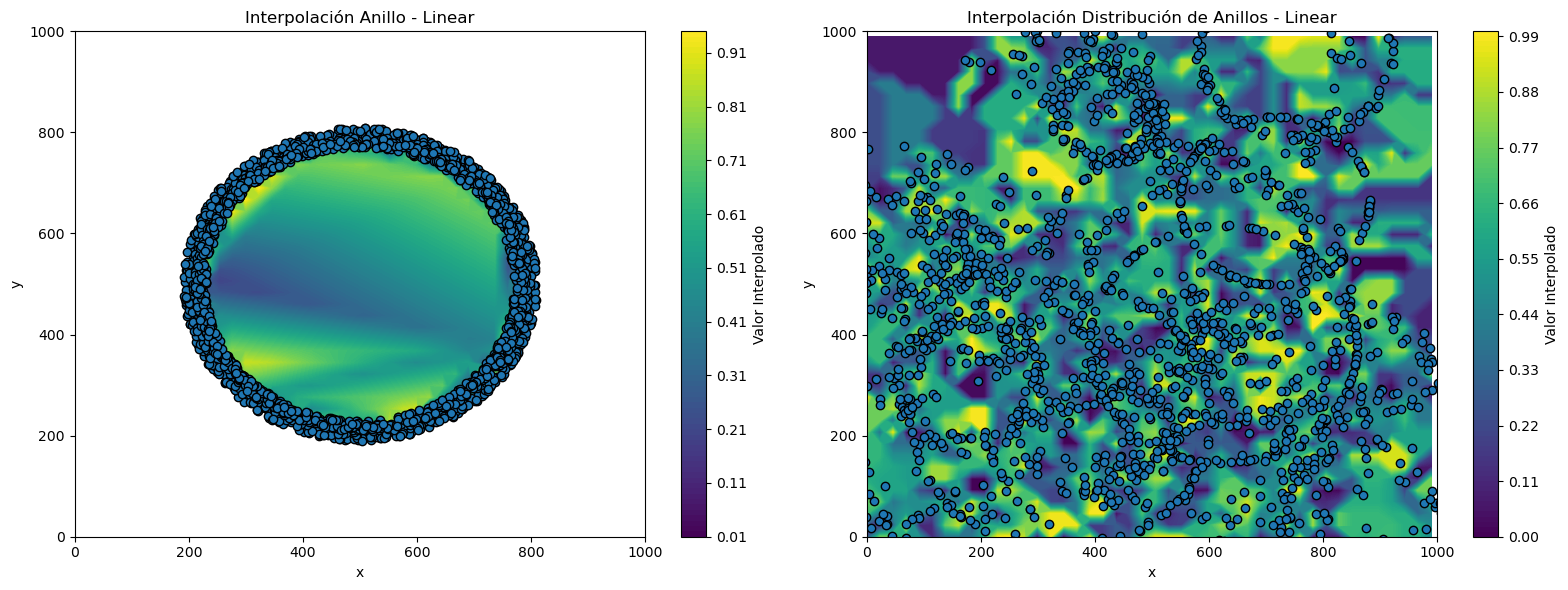

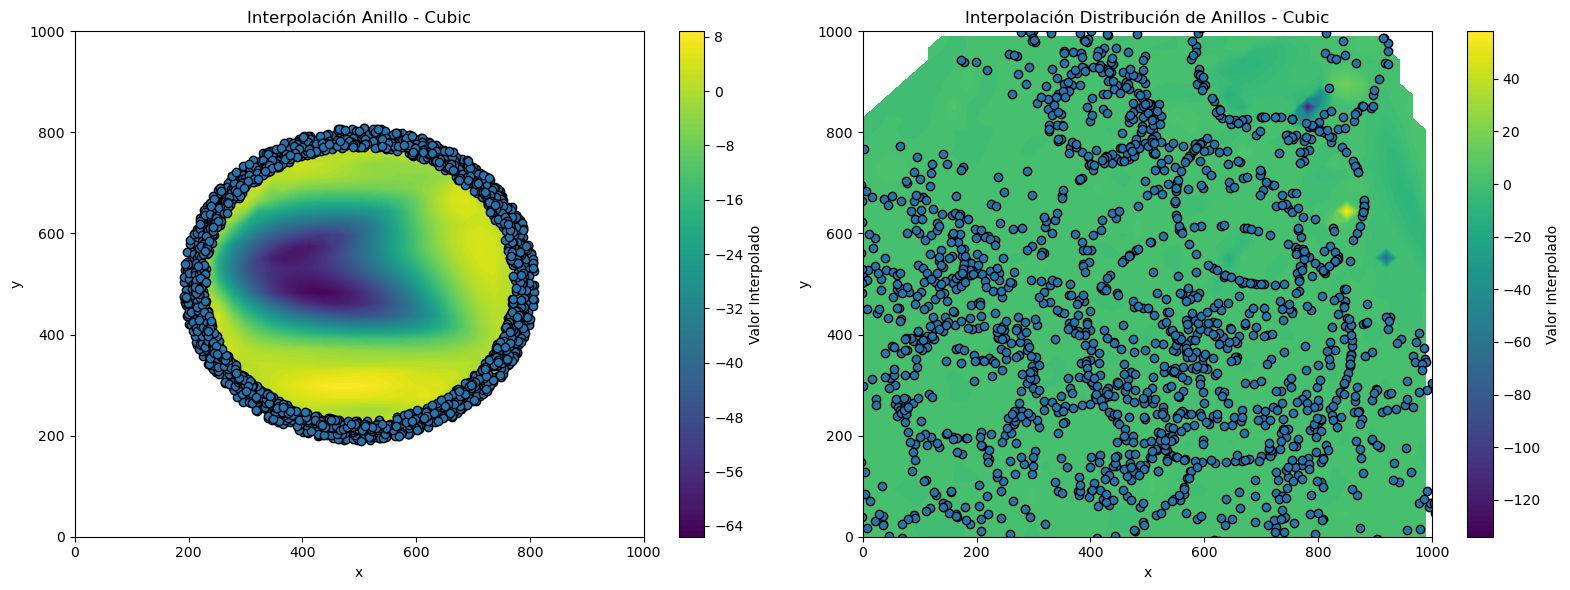

In [39]:
from scipy.interpolate import griddata

#==================================================================
# Generacion de la distribucion de anillos
#==================================================================
def anillos_distribuidos(num_centros, tam,num_p): #Funcion que grafica todos los anillos
    plt.figure(figsize=(8, 8)) #Inicia la figura
    puntos_anillos = [] #Lista que guardara todos los puntos generados
    for i in range(num_centros):
        centro=(uwu.random.uniform(0, tam), uwu.random.uniform(0, tam)) #Genera el centro aleatorio
        r1=uwu.random.uniform(1,tam/3.5)
        r2=uwu.random.uniform(r1,tam/3.5)
        p = spawn_puntos_anillo(num_p, tam,r1,r2,centro) #Genera los puntos, segun las caracteristicas anteriores
        puntos_anillos.append(p) #Va guardando cada anillo en la lista 
        #plt.scatter(p[:,0], p[:,1], alpha=0.5, s=5, color='blue') #Grafica el anillo generado de cada iteracion
    puntos_anillos = uwu.vstack(puntos_anillos) if puntos_anillos else uwu.array([]) # Transforma la lista de arrays en un solo array usando vstack
    return puntos_anillos

# Caracteristicas 
num_pal = 100  # Cantidad de puntos en cada anillo
tam=1000   #Tamaño del grafico
num_centros=20 #Numero de centros o anillos a graficar
nump_disan=int(num_pal*num_centros)

DisAnillos=anillos_distribuidos(num_centros,tam,num_pal)

LS_DisAnillos=LS(dim_hist, num_pa ,nump_disan,  bin_size, DisAnillos ,puntos_aleatorios) #Estimador usual para la distribucion de anillos

#======================================
# Creacion de la Malla
#======================================
lar_malla=1001 #Longitud de la malla
paso_malla=23 #Division de la malla
x_m=y_m=uwu.arange(0,lar_malla,paso_malla)
x_m,y_m=uwu.meshgrid(x_m,y_m)
z=uwu.random.random(2000)
z2=uwu.random.random(num_centros*num_pal)
#=====================================
# Interpolacion 
#=====================================

#--------Nearest--------------------------------------------

x_AU=Anillo_Unido[:,0]
y_AU=Anillo_Unido[:,1]

x_DA=DisAnillos[:,0]
y_DA=DisAnillos[:,1]

Inter_Anillo = griddata( Anillo_Unido, z ,( x_m , y_m ), method='nearest' )
Inter_DisAnillo =  griddata( DisAnillos, z2  ,( x_m , y_m ), method='nearest' )

#-----------Linear----------------------------------------------

Inter_Anillo_l = griddata( Anillo_Unido, z ,( x_m , y_m ), method='linear' )
Inter_DisAnillo_l=  griddata( DisAnillos, z2  ,( x_m , y_m ), method='linear' )

#--------------Cubic--------------------------------------------

Inter_Anillo_c = griddata( Anillo_Unido, z ,( x_m , y_m ), method='cubic' )
Inter_DisAnillo_c =  griddata( DisAnillos, z2  ,( x_m , y_m ), method='cubic' )

#=======================================
# Grafica de interpolacion 
#=======================================

#----------Nearest---------------------------------------------------

fig, axs = plt.subplots(1, 2, figsize=(16, 6))  # 1 fila, 2 columnas

# Primera gráfica
cf1 = axs[0].contourf(x_m, y_m, Inter_Anillo, levels=100, cmap='viridis')
fig.colorbar(cf1, ax=axs[0], label='Valor Interpolado')
axs[0].scatter(x_AU, y_AU, edgecolor='k')
axs[0].set_xlim(0, tam)
axs[0].set_ylim(0, tam)
axs[0].set_xlabel('x')
axs[0].set_ylabel('y')
axs[0].set_title('Interpolación Anillo - Nearest')

# Segunda gráfica
cf2 = axs[1].contourf(x_m, y_m, Inter_DisAnillo, levels=100, cmap='viridis')
fig.colorbar(cf2, ax=axs[1], label='Valor Interpolado')
axs[1].scatter(x_DA, y_DA, edgecolor='k')
axs[1].set_xlim(0, tam)
axs[1].set_ylim(0, tam)
axs[1].set_xlabel('x')
axs[1].set_ylabel('y')
axs[1].set_title('Interpolación Distribución de Anillos - Nearest')

plt.tight_layout()
plt.show()

#-------Linear---------------------------------------

fig, axs = plt.subplots(1, 2, figsize=(16, 6))  # 1 fila, 2 columnas
# Primera gráfica
cf1 = axs[0].contourf(x_m, y_m, Inter_Anillo_l, levels=100, cmap='viridis')
fig.colorbar(cf1, ax=axs[0], label='Valor Interpolado')
axs[0].scatter(x_AU, y_AU, edgecolor='k')
axs[0].set_xlim(0, tam)
axs[0].set_ylim(0, tam)
axs[0].set_xlabel('x')
axs[0].set_ylabel('y')
axs[0].set_title('Interpolación Anillo - Linear')

# Segunda gráfica
cf2 = axs[1].contourf(x_m, y_m, Inter_DisAnillo, levels=100, cmap='viridis')
fig.colorbar(cf2, ax=axs[1], label='Valor Interpolado')
axs[1].scatter(x_DA, y_DA, edgecolor='k')
axs[1].set_xlim(0, tam)
axs[1].set_ylim(0, tam)
axs[1].set_xlabel('x')
axs[1].set_ylabel('y')
axs[1].set_title('Interpolación Distribución de Anillos - Linear')

plt.tight_layout()
plt.show()

#------------------Cubic-----------------------------
fig, axs = plt.subplots(1, 2, figsize=(16, 6))  # 1 fila, 2 columnas
# Primera gráfica
cf1 = axs[0].contourf(x_m, y_m, Inter_Anillo_c, levels=100, cmap='viridis')
fig.colorbar(cf1, ax=axs[0], label='Valor Interpolado')
axs[0].scatter(x_AU, y_AU, edgecolor='k')
axs[0].set_xlim(0, tam)
axs[0].set_ylim(0, tam)
axs[0].set_xlabel('x')
axs[0].set_ylabel('y')
axs[0].set_title('Interpolación Anillo - Cubic')

# Segunda gráfica
cf2 = axs[1].contourf(x_m, y_m, Inter_DisAnillo_c, levels=100, cmap='viridis')
fig.colorbar(cf2, ax=axs[1], label='Valor Interpolado')
axs[1].scatter(x_DA, y_DA, edgecolor='k')
axs[1].set_xlim(0, tam)
axs[1].set_ylim(0, tam)
axs[1].set_xlabel('x')
axs[1].set_ylabel('y')
axs[1].set_title('Interpolación Distribución de Anillos - Cubic')

plt.tight_layout()
plt.show()


### b)

0.001936


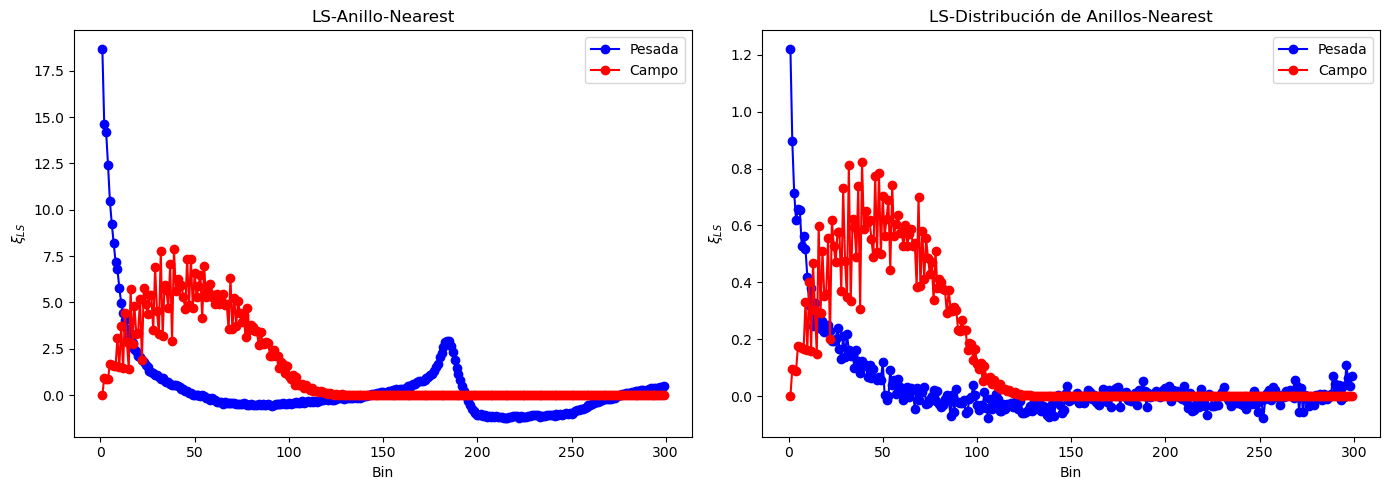

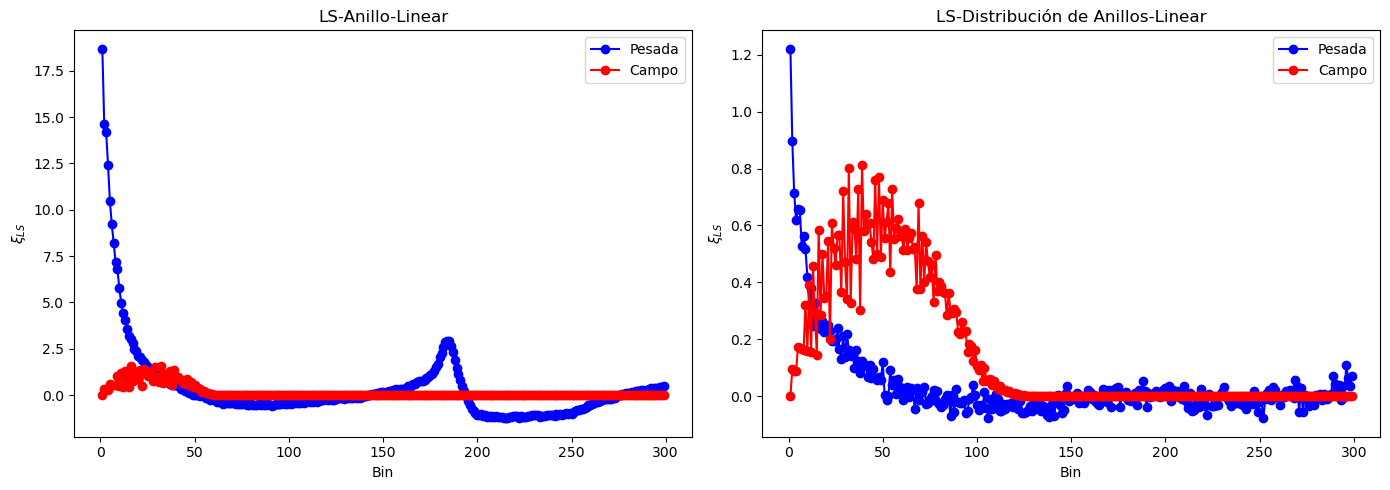

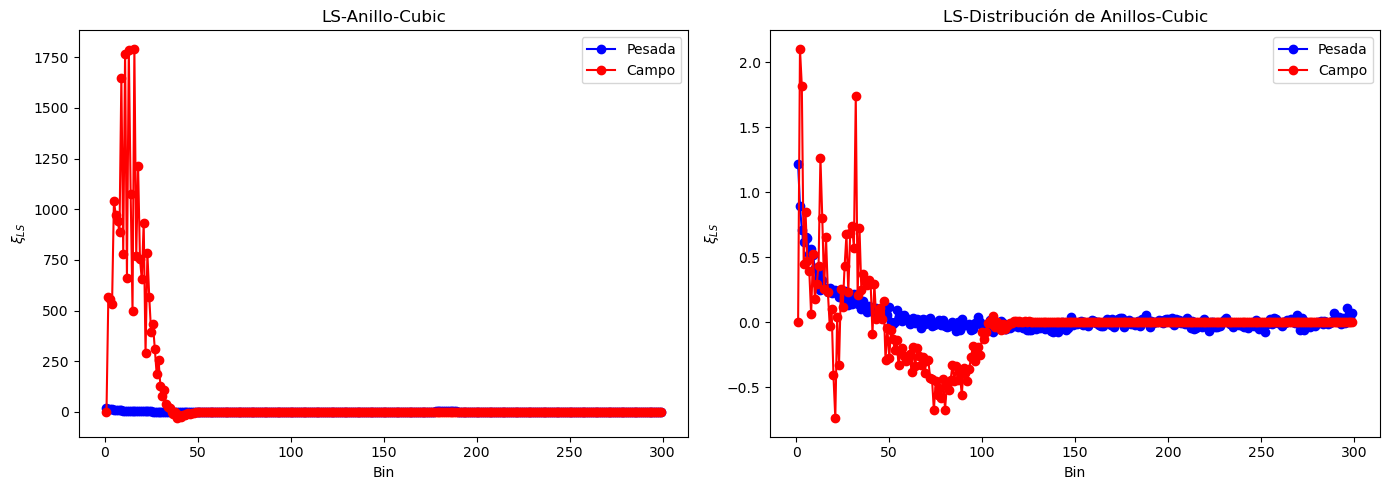

In [41]:
# Funcion de correlacion del campo 

puntos_campo= uwu.column_stack([x_m.ravel(), y_m.ravel()]) #Coordenadas de la malla donde se interpolo
nump_campo=int(puntos_campo.shape[0]) #Numero de puntos del campo
densidad_prom_campo=nump_campo/(L**2) #Densidad promedio del campo
print(densidad_prom_campo)
bin_size_campo=10 #Aumente el tamaño del bin para analizar la interpolacion como fue recomendado
#==============================================================
# LS Anillo Nearest
#==============================================================
pesos_Anillo=Inter_Anillo.ravel().reshape(-1, 1) #Acomoda los pesos del campo en un arreglo Nx1, correspondiente a
#cada posicion en la malla de interpolacion (con el .reshape(-1,1)) ya que ".ravel" lo acomoda en un arreglo 1xN
pesos_campo_Anillo= uwu.nan_to_num(pesos_Anillo, nan=0.0)
pesos_campo_Anillo_corre=(pesos_campo_Anillo - densidad_prom_campo)/densidad_prom_campo #Ahora si use lo de restarle la densidad para obtener la funcion
#de correlacion a partir del histograma.

pesos_DisAnillo=Inter_DisAnillo.ravel().reshape(-1,1)
pesos_campo_DisAnillo = uwu.nan_to_num(pesos_DisAnillo, nan=0.0)
pesos_campo_DisAnillo_corre=(pesos_campo_DisAnillo - densidad_prom_campo)/densidad_prom_campo

Campo_Anillo_Near=uwu.hstack((puntos_campo,pesos_campo_Anillo)) #Genera la malla y su peso en un arreglo Nx3
Campo_DisAnillo_Near=uwu.hstack((puntos_campo,pesos_campo_DisAnillo))

LS_Campo_Anillo = Histo_distancias_pesado(dim_hist, nump_campo, Campo_Anillo_Near, bin_size_campo)
LS_Campo_DisAnillo = Histo_distancias_pesado(dim_hist, nump_campo, Campo_DisAnillo_Near, bin_size_campo)


LS_Campo_DisAnillo_N=LS_Campo_DisAnillo/1e4 #lo normalizo a esa magnitud para hacero comparable con el histograma usual 
LS_Campo_Anillo_N=LS_Campo_Anillo/1e3


fig, axs = plt.subplots(1, 2, figsize=(14, 5))  # 1 fila, 2 columnas
axs[0].plot(range(1, dim_hist), LS_Anillo_pesado[1:], marker='o', color='b', linestyle="solid", label='Pesada')
axs[0].plot(range(1, dim_hist), LS_Campo_Anillo_N[1:], marker='o', color='r', linestyle="solid", label='Campo')
axs[0].set_xlabel("Bin")
axs[0].set_ylabel(r"$\xi_{LS}$")
axs[0].set_title("LS-Anillo-Nearest")
axs[0].legend()
axs[1].plot(range(1, dim_hist), LS_DisAnillos[1:], marker='o', color='b', linestyle="solid", label='Pesada')
axs[1].plot(range(1, dim_hist), LS_Campo_DisAnillo_N[1:], marker='o', color='r', linestyle="solid", label='Campo')
axs[1].set_xlabel("Bin")
axs[1].set_ylabel(r"$\xi_{LS}$")
axs[1].set_title("LS-Distribución de Anillos-Nearest")
axs[1].legend()
plt.tight_layout()
plt.show()

#==============================================================
# LS Anillo Linear
#==============================================================
pesos_Anillo_l=Inter_Anillo_l.ravel().reshape(-1, 1) #Acomoda los pesos del campo en un arreglo Nx1, correspondiente a
#cada posicion en la malla de interpolacion (con el .reshape(-1,1)) ya que ".ravel" lo acomoda en un arreglo 1xN
pesos_campo_Anillo_l= uwu.nan_to_num(pesos_Anillo_l, nan=0.0)
pesos_campo_Anillo_l_corre=(pesos_campo_Anillo_l - densidad_prom_campo)/densidad_prom_campo

pesos_DisAnillo_l=Inter_DisAnillo_l.ravel().reshape(-1,1)
pesos_campo_DisAnillo_l = uwu.nan_to_num(pesos_DisAnillo_l, nan=0.0)
pesos_campo_DisAnillo_l_corre=(pesos_campo_DisAnillo_l - densidad_prom_campo)/densidad_prom_campo

Campo_Anillo_l=uwu.hstack((puntos_campo,pesos_campo_Anillo_l)) #Genera la malla y su peso en un arreglo Nx3
Campo_DisAnillo_l=uwu.hstack((puntos_campo,pesos_campo_DisAnillo_l))

LS_Campo_Anillo_l = Histo_distancias_pesado(dim_hist, nump_campo, Campo_Anillo_l, bin_size_campo)
LS_Campo_DisAnillo_l = Histo_distancias_pesado(dim_hist, nump_campo, Campo_DisAnillo_l, bin_size_campo)


LS_Campo_DisAnillo_l_N=LS_Campo_DisAnillo_l/1e4 #lo normalizo a esa magnitud para hacero comparable con el histograma usual 
LS_Campo_Anillo_l_N=LS_Campo_Anillo_l/1e3

fig, axs = plt.subplots(1, 2, figsize=(14, 5))  # 1 fila, 2 columnas
axs[0].plot(range(1, dim_hist), LS_Anillo_pesado[1:], marker='o', color='b', linestyle="solid", label='Pesada')
axs[0].plot(range(1, dim_hist), LS_Campo_Anillo_l_N[1:], marker='o', color='r', linestyle="solid", label='Campo')
axs[0].set_xlabel("Bin")
axs[0].set_ylabel(r"$\xi_{LS}$")
axs[0].set_title("LS-Anillo-Linear")
axs[0].legend()
axs[1].plot(range(1, dim_hist), LS_DisAnillos[1:], marker='o', color='b', linestyle="solid", label='Pesada')
axs[1].plot(range(1, dim_hist), LS_Campo_DisAnillo_l_N[1:], marker='o', color='r', linestyle="solid", label='Campo')
axs[1].set_xlabel("Bin")
axs[1].set_ylabel(r"$\xi_{LS}$")
axs[1].set_title("LS-Distribución de Anillos-Linear")
axs[1].legend()
plt.tight_layout()
plt.show()

#================================================================
#LS Anillos Cubic
#=================================================================

pesos_Anillo_c=Inter_Anillo_c.ravel().reshape(-1, 1) #Acomoda los pesos del campo en un arreglo Nx1, correspondiente a
#cada posicion en la malla de interpolacion (con el .reshape(-1,1)) ya que ".ravel" lo acomoda en un arreglo 1xN
pesos_campo_Anillo_c= uwu.nan_to_num(pesos_Anillo_c, nan=0.0)
pesos_campo_Anillo_c_corre=(pesos_campo_Anillo_c - densidad_prom_campo)/densidad_prom_campo

pesos_DisAnillo_c=Inter_DisAnillo_c.ravel().reshape(-1,1)
pesos_campo_DisAnillo_c = uwu.nan_to_num(pesos_DisAnillo_c, nan=0.0)
pesos_campo_DisAnillo_c_corre=(pesos_campo_DisAnillo_c - densidad_prom_campo)/densidad_prom_campo

Campo_Anillo_c=uwu.hstack((puntos_campo,pesos_campo_Anillo_c)) #Genera la malla y su peso en un arreglo Nx3
Campo_DisAnillo_c=uwu.hstack((puntos_campo,pesos_campo_DisAnillo_c))

LS_Campo_Anillo_c = Histo_distancias_pesado(dim_hist, nump_campo, Campo_Anillo_c, bin_size_campo)
LS_Campo_DisAnillo_c = Histo_distancias_pesado(dim_hist, nump_campo, Campo_DisAnillo_c, bin_size_campo)


LS_Campo_DisAnillo_c_N=LS_Campo_DisAnillo_c/1e4 #lo normalizo a esa magnitud para hacero comparable con el histograma usual 
LS_Campo_Anillo_c_N=LS_Campo_Anillo_c/1e3

fig, axs = plt.subplots(1, 2, figsize=(14, 5))  # 1 fila, 2 columnas
axs[0].plot(range(1, dim_hist), LS_Anillo_pesado[1:], marker='o', color='b', linestyle="solid", label='Pesada')
axs[0].plot(range(1, dim_hist), LS_Campo_Anillo_c_N[1:], marker='o', color='r', linestyle="solid", label='Campo')
axs[0].set_xlabel("Bin")
axs[0].set_ylabel(r"$\xi_{LS}$")
axs[0].set_title("LS-Anillo-Cubic")
axs[0].legend()
axs[1].plot(range(1, dim_hist), LS_DisAnillos[1:], marker='o', color='b', linestyle="solid", label='Pesada')
axs[1].plot(range(1, dim_hist), LS_Campo_DisAnillo_c_N[1:], marker='o', color='r', linestyle="solid", label='Campo')
axs[1].set_xlabel("Bin")
axs[1].set_ylabel(r"$\xi_{LS}$")
axs[1].set_title("LS-Distribución de Anillos-Cubic")
axs[1].legend()
plt.tight_layout()
plt.show()


### c)

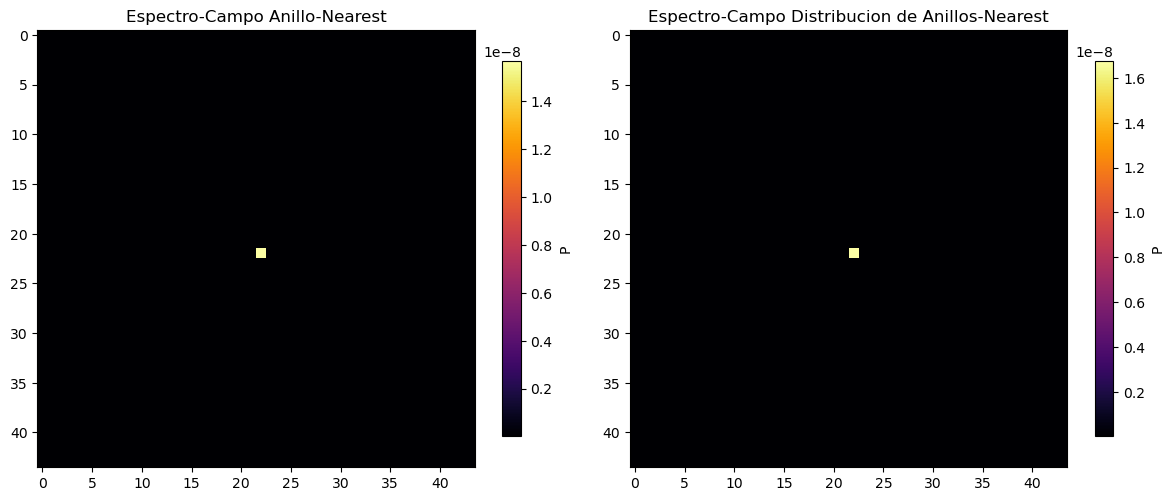

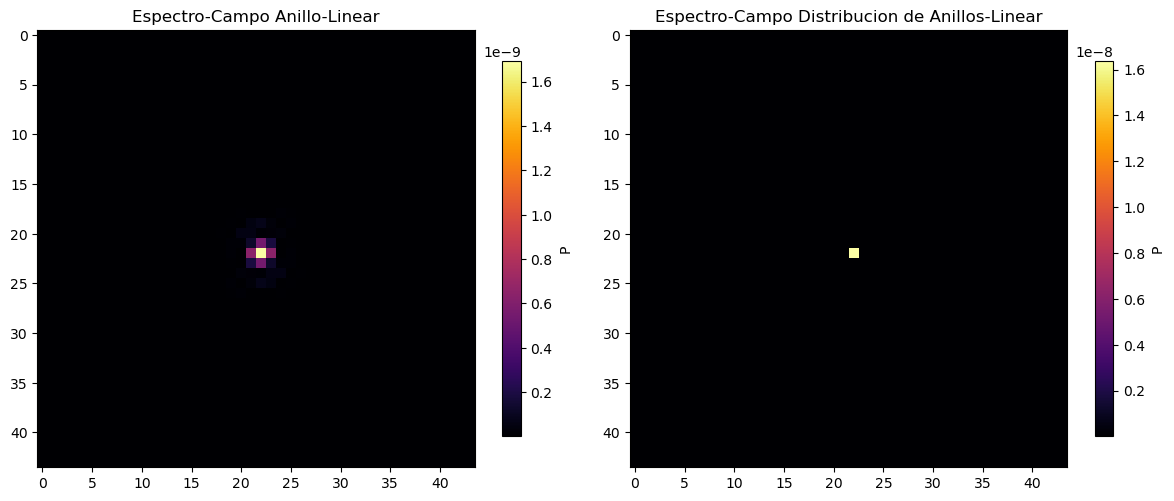

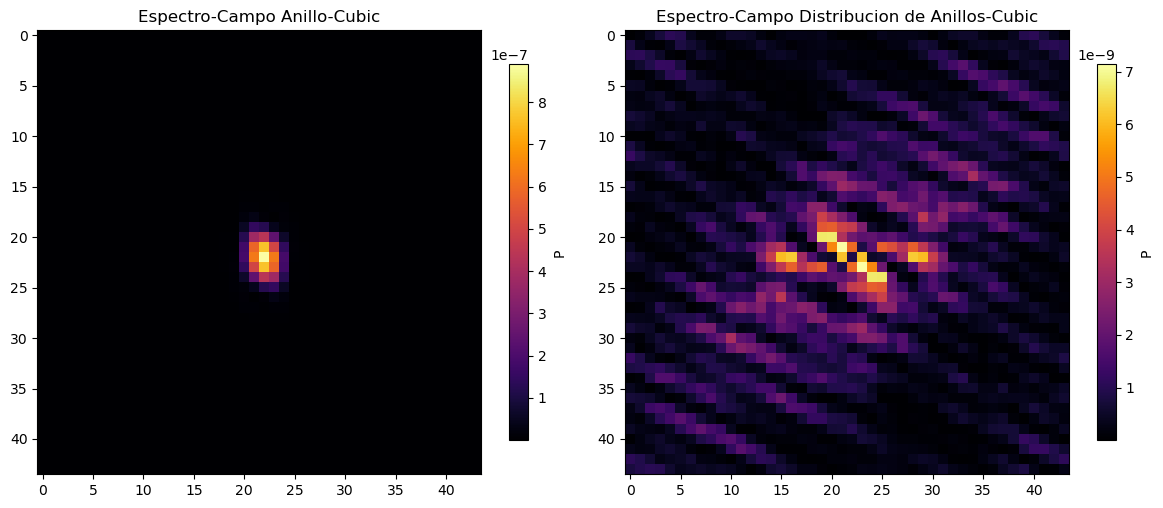

In [43]:
#==================================================
#Transformada de Fourier
#==================================================
V=tam*tam #Volumen de la malla
N=nump_campo**6
Fac_Nor_Espectro=V/N
#-------------Nearest-------------------------------------------

Inter_Anillo_Corregido = uwu.nan_to_num(Inter_Anillo, nan=0.0)
Inter_DisAnillo_Corregido= uwu.nan_to_num(Inter_DisAnillo, nan=0.0)

FFT_Anillo_Near = uwu.fft.fft2(Inter_Anillo_Corregido) #Transformada de la malla
FFT_Anillo_Near_shifted = uwu.fft.fftshift(FFT_Anillo_Near) #Centra las frecuencias grandes
FFT2_Anillo_Near = Fac_Nor_Espectro*uwu.abs(FFT_Anillo_Near_shifted)**2 #Magnitud de la transfor

FFT_DisAnillo_Near = uwu.fft.fft2(Inter_DisAnillo_Corregido) #Transformada de la malla
FFT_DisAnillo_Near_shifted = uwu.fft.fftshift(FFT_DisAnillo_Near) #Centra las frecuencias grandes
FFT2_DisAnillo_Near = Fac_Nor_Espectro*uwu.abs(FFT_DisAnillo_Near_shifted)**2 #Magnitud de la transfor

fig, axs = plt.subplots(1, 2, figsize=(12, 5))  # 1 fila, 2 columnas
im1 = axs[0].imshow(FFT2_Anillo_Near, cmap='inferno')
axs[0].set_title("Espectro-Campo Anillo-Nearest")
cbar1=fig.colorbar(im1, ax=axs[0], shrink=0.8)
cbar1.set_label("P")
im2 = axs[1].imshow(FFT2_DisAnillo_Near, cmap='inferno')
axs[1].set_title("Espectro-Campo Distribucion de Anillos-Nearest")
cbar2=fig.colorbar(im2, ax=axs[1], shrink=0.8)
cbar2.set_label("P")
plt.tight_layout()
plt.show()
#-------------Linear--------------------------------------------

Inter_Anillo_l_Corregido = uwu.nan_to_num(Inter_Anillo_l, nan=0.0)
Inter_DisAnillo_l_Corregido= uwu.nan_to_num(Inter_DisAnillo_l, nan=0.0)

FFT_Anillo_l = uwu.fft.fft2(Inter_Anillo_l_Corregido) #Transformada de la malla
FFT_Anillo_l_shifted = uwu.fft.fftshift(FFT_Anillo_l) #Centra las frecuencias grandes
FFT2_Anillo_l = Fac_Nor_Espectro*uwu.abs(FFT_Anillo_l_shifted)**2 #Magnitud de la transfor

FFT_DisAnillo_l = uwu.fft.fft2(Inter_DisAnillo_l_Corregido) #Transformada de la malla
FFT_DisAnillo_l_shifted = uwu.fft.fftshift(FFT_DisAnillo_l) #Centra las frecuencias grandes
FFT2_DisAnillo_l = Fac_Nor_Espectro*uwu.abs(FFT_DisAnillo_l_shifted)**2 #Magnitud de la transfor

fig, axs = plt.subplots(1, 2, figsize=(12, 5))  # 1 fila, 2 columnas
im1 = axs[0].imshow(FFT2_Anillo_l, cmap='inferno')
axs[0].set_title("Espectro-Campo Anillo-Linear")
cbar1=fig.colorbar(im1, ax=axs[0], shrink=0.8)
cbar1.set_label("P")
im2 = axs[1].imshow(FFT2_DisAnillo_l, cmap='inferno')
axs[1].set_title("Espectro-Campo Distribucion de Anillos-Linear")
cbar2=fig.colorbar(im2, ax=axs[1], shrink=0.8)
cbar2.set_label("P")
plt.tight_layout()
plt.show()

#-------------------Cubic----------------------------------------

Inter_Anillo_c_Corregido = uwu.nan_to_num(Inter_Anillo_c, nan=0.0)
Inter_DisAnillo_c_Corregido= uwu.nan_to_num(Inter_DisAnillo_c, nan=0.0)

FFT_Anillo_c = uwu.fft.fft2(Inter_Anillo_c_Corregido) #Transformada de la malla
FFT_Anillo_c_shifted = uwu.fft.fftshift(FFT_Anillo_c) #Centra las frecuencias grandes
FFT2_Anillo_c = Fac_Nor_Espectro*uwu.abs(FFT_Anillo_c_shifted)**2 #Magnitud de la transfor

FFT_DisAnillo_c = uwu.fft.fft2(Inter_DisAnillo_c_Corregido) #Transformada de la malla
FFT_DisAnillo_c_shifted = uwu.fft.fftshift(FFT_DisAnillo_c) #Centra las frecuencias grandes
FFT2_DisAnillo_c = Fac_Nor_Espectro*uwu.abs(FFT_DisAnillo_c_shifted)**2 #Magnitud de la transfor

fig, axs = plt.subplots(1, 2, figsize=(12, 5))  # 1 fila, 2 columnas
im1 = axs[0].imshow(FFT2_Anillo_c, cmap='inferno')
axs[0].set_title("Espectro-Campo Anillo-Cubic")
cbar1=fig.colorbar(im1, ax=axs[0], shrink=0.8)
cbar1.set_label("P")
im2 = axs[1].imshow(FFT2_DisAnillo_c, cmap='inferno')
axs[1].set_title("Espectro-Campo Distribucion de Anillos-Cubic")
cbar2=fig.colorbar(im2, ax=axs[1], shrink=0.8)
cbar2.set_label("P")
plt.tight_layout()
plt.show()


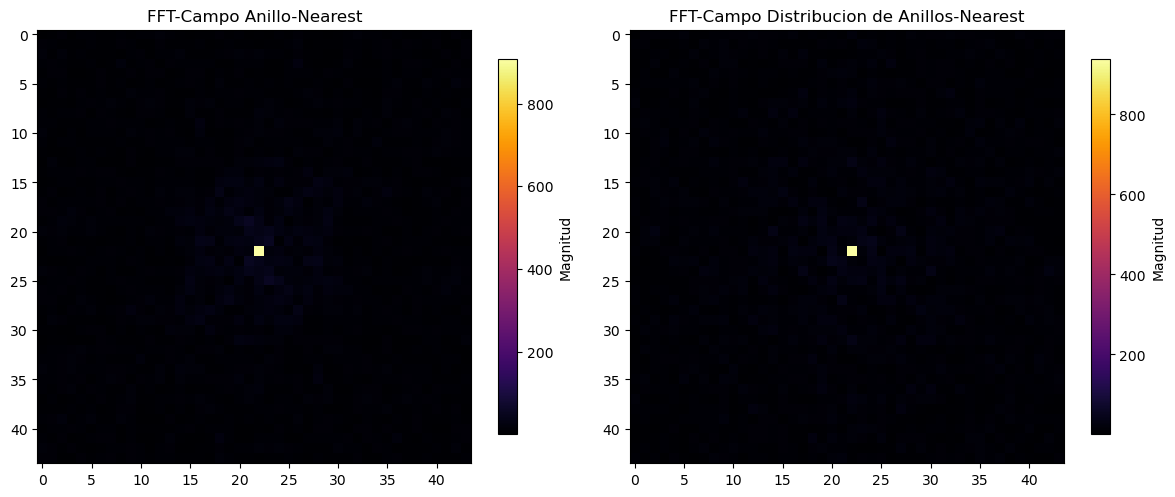

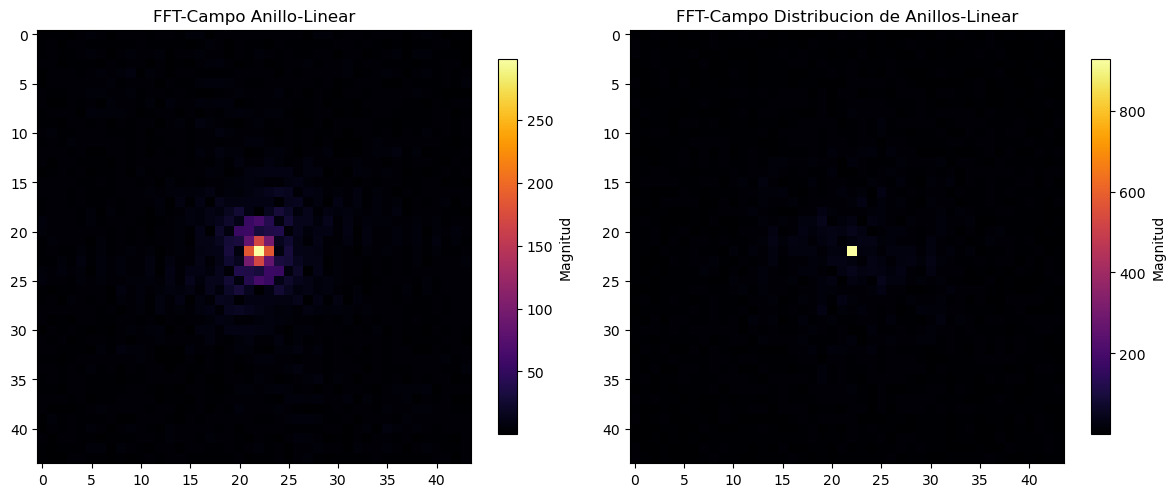

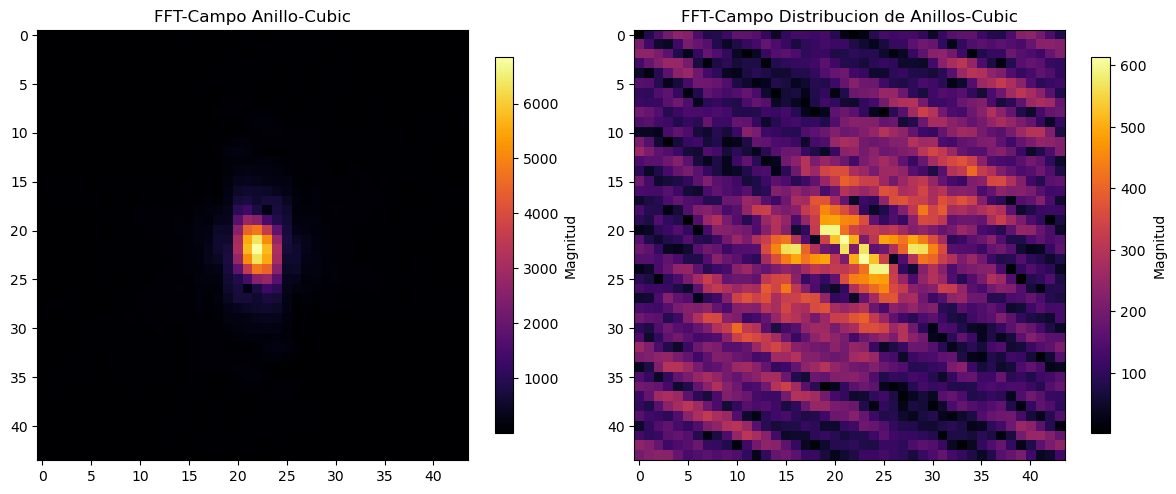

In [44]:
#===================================================
#Transformada en el espacio de Fourier
#======================================================
#-------------Nearest-------------------------------------------

Inter_Anillo_Corregido = uwu.nan_to_num(Inter_Anillo, nan=0.0)
Inter_DisAnillo_Corregido= uwu.nan_to_num(Inter_DisAnillo, nan=0.0)

FFT_Anillo_Near = uwu.fft.fft2(Inter_Anillo_Corregido) #Transformada de la malla
FFT_Anillo_Near_shifted = uwu.fft.fftshift(FFT_Anillo_Near) #Centra las frecuencias grandes
FFT2_Anillo_Near = uwu.abs(FFT_Anillo_Near_shifted) #Magnitud de la transfor

FFT_DisAnillo_Near = uwu.fft.fft2(Inter_DisAnillo_Corregido) #Transformada de la malla
FFT_DisAnillo_Near_shifted = uwu.fft.fftshift(FFT_DisAnillo_Near) #Centra las frecuencias grandes
FFT2_DisAnillo_Near = uwu.abs(FFT_DisAnillo_Near_shifted) #Magnitud de la transfor

fig, axs = plt.subplots(1, 2, figsize=(12, 5))  # 1 fila, 2 columnas
im1 = axs[0].imshow(FFT2_Anillo_Near, cmap='inferno')
axs[0].set_title("FFT-Campo Anillo-Nearest")
cbar1=fig.colorbar(im1, ax=axs[0], shrink=0.8)
cbar1.set_label("Magnitud")
im2 = axs[1].imshow(FFT2_DisAnillo_Near, cmap='inferno')
axs[1].set_title("FFT-Campo Distribucion de Anillos-Nearest")
cbar2=fig.colorbar(im2, ax=axs[1], shrink=0.8)
cbar2.set_label("Magnitud")
plt.tight_layout()
plt.show()
#-------------Linear--------------------------------------------

Inter_Anillo_l_Corregido = uwu.nan_to_num(Inter_Anillo_l, nan=0.0)
Inter_DisAnillo_l_Corregido= uwu.nan_to_num(Inter_DisAnillo_l, nan=0.0)

FFT_Anillo_l = uwu.fft.fft2(Inter_Anillo_l_Corregido) #Transformada de la malla
FFT_Anillo_l_shifted = uwu.fft.fftshift(FFT_Anillo_l) #Centra las frecuencias grandes
FFT2_Anillo_l = uwu.abs(FFT_Anillo_l_shifted) #Magnitud de la transfor

FFT_DisAnillo_l = uwu.fft.fft2(Inter_DisAnillo_l_Corregido) #Transformada de la malla
FFT_DisAnillo_l_shifted = uwu.fft.fftshift(FFT_DisAnillo_l) #Centra las frecuencias grandes
FFT2_DisAnillo_l = uwu.abs(FFT_DisAnillo_l_shifted) #Magnitud de la transfor

fig, axs = plt.subplots(1, 2, figsize=(12, 5))  # 1 fila, 2 columnas
im1 = axs[0].imshow(FFT2_Anillo_l, cmap='inferno')
axs[0].set_title("FFT-Campo Anillo-Linear")
cbar1=fig.colorbar(im1, ax=axs[0], shrink=0.8)
cbar1.set_label("Magnitud")
im2 = axs[1].imshow(FFT2_DisAnillo_l, cmap='inferno')
axs[1].set_title("FFT-Campo Distribucion de Anillos-Linear")
cbar2=fig.colorbar(im2, ax=axs[1], shrink=0.8)
cbar2.set_label("Magnitud")
plt.tight_layout()
plt.show()

#-------------------Cubic----------------------------------------

Inter_Anillo_c_Corregido = uwu.nan_to_num(Inter_Anillo_c, nan=0.0)
Inter_DisAnillo_c_Corregido= uwu.nan_to_num(Inter_DisAnillo_c, nan=0.0)

FFT_Anillo_c = uwu.fft.fft2(Inter_Anillo_c_Corregido) #Transformada de la malla
FFT_Anillo_c_shifted = uwu.fft.fftshift(FFT_Anillo_c) #Centra las frecuencias grandes
FFT2_Anillo_c = uwu.abs(FFT_Anillo_c_shifted) #Magnitud de la transfor

FFT_DisAnillo_c = uwu.fft.fft2(Inter_DisAnillo_c_Corregido) #Transformada de la malla
FFT_DisAnillo_c_shifted = uwu.fft.fftshift(FFT_DisAnillo_c) #Centra las frecuencias grandes
FFT2_DisAnillo_c = uwu.abs(FFT_DisAnillo_c_shifted) #Magnitud de la transfor

fig, axs = plt.subplots(1, 2, figsize=(12, 5))  # 1 fila, 2 columnas
im1 = axs[0].imshow(FFT2_Anillo_c, cmap='inferno')
axs[0].set_title("FFT-Campo Anillo-Cubic")
cbar1=fig.colorbar(im1, ax=axs[0], shrink=0.8)
cbar1.set_label("Magnitud")
im2 = axs[1].imshow(FFT2_DisAnillo_c, cmap='inferno')
axs[1].set_title("FFT-Campo Distribucion de Anillos-Cubic")
cbar2=fig.colorbar(im2, ax=axs[1], shrink=0.8)
cbar2.set_label("Magnitud")
plt.tight_layout()
plt.show()


### d)

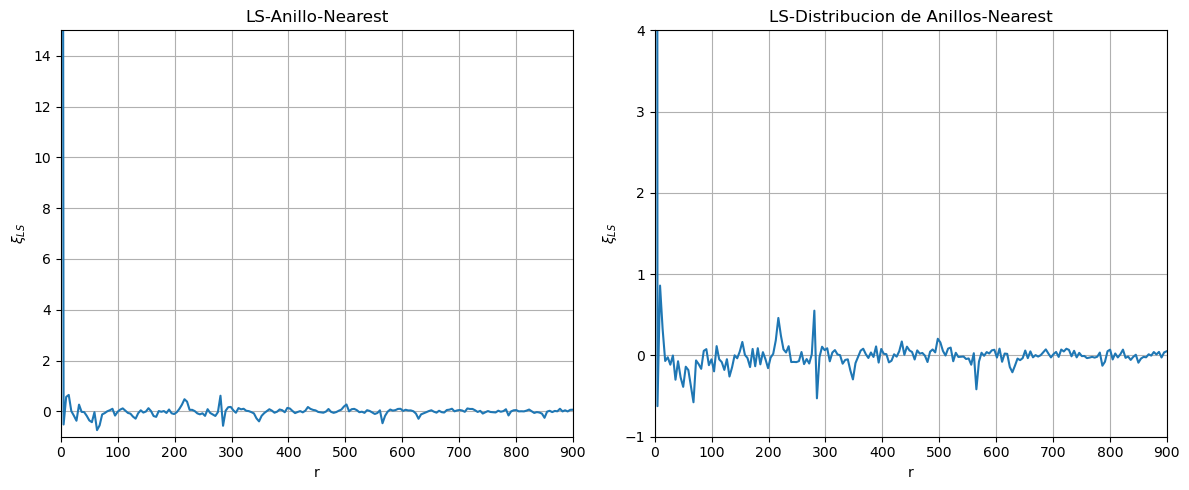

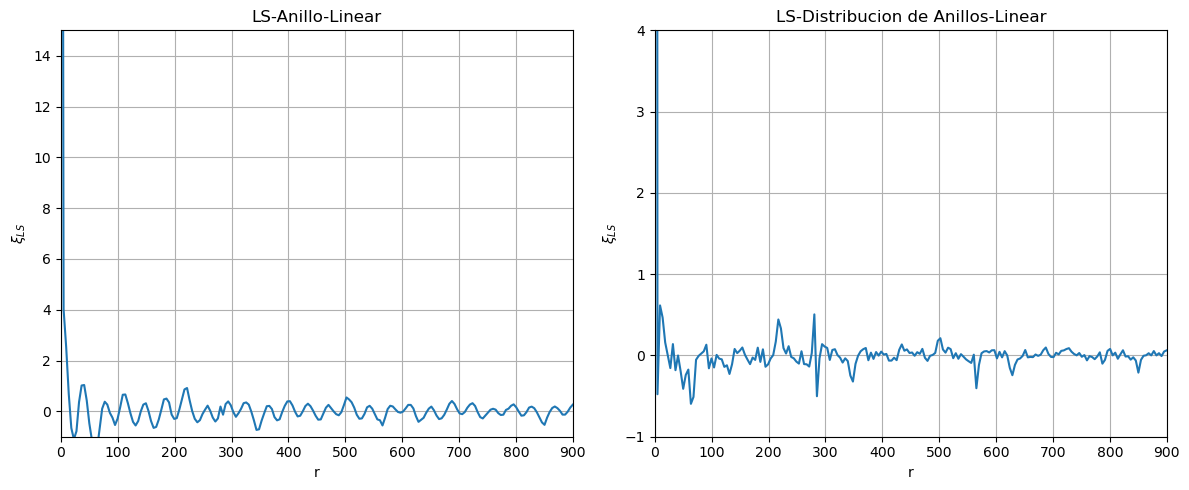

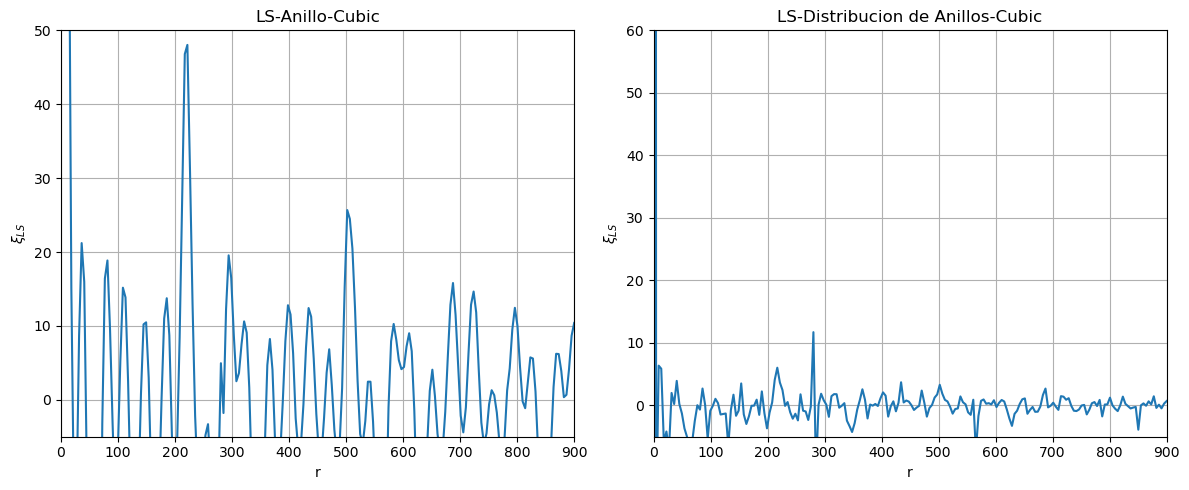

In [46]:
from scipy.special import j0  # Bessel function of order 0

def LS_Espectro(FFT2_DisAnillo_c, num_bins,num_r,r_max): #Calcula el estimador LS en funcion del radio del espectro 2D
    N = FFT2_DisAnillo_c.shape[0]  #Da las dimensiones del arreglo para kx y ky 
    kx = uwu.fft.fftfreq(N) *2*uwu.pi  #Genera los valores de kx del espectro, lo cambiamos a radianes para la transformada
    ky = uwu.fft.fftfreq(N)*2*uwu.pi #Genera los valores de ky del espectro
    KX, KY = uwu.meshgrid(kx, ky) #Genera la malla pero con las coordenadas (kx,ky) correspondientes

    # Espectro con la magnitud correspondiente a su punto
    K = uwu.sqrt(KX**2 + KY**2).flatten() #Genera un arreglo plano con todas las magnitudes de las coordenadas en la malla.
    Espectro_flat = FFT2_DisAnillo_c.flatten() #Aplana el espectro, para que coincida con el arreglo de las magnitudes.

    #Bins de k
    k_bins = uwu.linspace(0, K.max(), num_bins+1) #Voy a binear de 0 hasta la magnitud maxima obtenida en K
    k_centers = 0.5 * (k_bins[:-1] + k_bins[1:]) #Cbda bin se representa por un valor k caracteristico, en este caso, el valor medio en cada bin de K
    #(se va a usar para evaluar la funcion al momento de calcular la funcion de correlacion).
    
    # Promediar espectro en cada bin
    Espectro_r = uwu.zeros(num_bins)
    for i in range(num_bins):
        indices = uwu.where((K >= k_bins[i]) & (K < k_bins[i+1]))[0] #Obtiene los indices donde se cumple la condicion del bin
        if len(indices) > 0:
            Espectro_r[i] = Espectro_flat[indices].mean() #Calcula el promedio de los indices donde se cumple, o sea de la funcion para dicho k
        else:
            Espectro_r[i] = 0
    #Integramos sobre k para obtener la funcion de correlacion 
    r_max=900 #Radio maximo hasta donde se va a calcular la funcion de correlacion 
    num_r=200 #Numero de puntos en la funcion de correlacion
    r = uwu.linspace(0, r_max, num_r)  # radios analizados para la funcion de correlacion 
    LS_r = uwu.zeros_like(r) #Un arreglo de la misma dimension que r
    for i, radius in enumerate(r):
        integrand =k_centers * Espectro_r * j0(k_centers * radius) #De la formula que vimos en clase para 2D
        LS_r[i] = uwu.trapz(integrand, k_centers) #Integramos por el metodo del trapecio
    return LS_r
    
#========================================================================================
# Caracteristicas de la integracion de los espectros
#=========================================================================================

r_max=900 #Radio maximo hasta donde se va a calcular la funcion de correlacion 
num_r=200 #Numero de puntos en la funcion de correlacion
num_bins = 200 #Numero de bines en el espacio k, entre mas bines mejor resolucion. al igual que en num_r
r = uwu.linspace(0, r_max, num_r)


#=========================================================================================
# Nearest
#=========================================================================================

LS_Espectro_Anillo_Near=LS_Espectro(FFT2_Anillo_Near, num_bins,num_r,r_max)
LS_Espectro_DisAnillo_Near=LS_Espectro(FFT2_DisAnillo_Near, num_bins,num_r,r_max)

fig, axs = plt.subplots(1, 2, figsize=(12, 5)) 
axs[0].plot(r, LS_Espectro_Anillo_Near)
axs[0].set_xlabel('r')
axs[0].set_ylabel(r"$\xi_{LS}$")
axs[0].set_title('LS-Anillo-Nearest')
axs[0].set_xlim(0, r_max)
axs[0].set_ylim(-1, 15)
axs[0].grid(True)
axs[1].plot(r, LS_Espectro_DisAnillo_Near)
axs[1].set_xlabel('r')
axs[1].set_ylabel(r"$\xi_{LS}$")
axs[1].set_title('LS-Distribucion de Anillos-Nearest')
axs[1].set_xlim(0, r_max)
axs[1].set_ylim(-1, 4)
axs[1].grid(True)
plt.tight_layout()
plt.show()


#=========================================================================================
# Linear
#=========================================================================================

LS_Espectro_Anillo_l=LS_Espectro(FFT2_Anillo_l, num_bins,num_r,r_max)
LS_Espectro_DisAnillo_l=LS_Espectro(FFT2_DisAnillo_l, num_bins,num_r,r_max)

fig, axs = plt.subplots(1, 2, figsize=(12, 5)) 
axs[0].plot(r, LS_Espectro_Anillo_l)
axs[0].set_xlabel('r')
axs[0].set_ylabel(r"$\xi_{LS}$")
axs[0].set_title('LS-Anillo-Linear')
axs[0].set_xlim(0, r_max)
axs[0].set_ylim(-1, 15)
axs[0].grid(True)
axs[1].plot(r, LS_Espectro_DisAnillo_l)
axs[1].set_xlabel('r')
axs[1].set_ylabel(r"$\xi_{LS}$")
axs[1].set_title('LS-Distribucion de Anillos-Linear')
axs[1].set_xlim(0, r_max)
axs[1].set_ylim(-1, 4)
axs[1].grid(True)
plt.tight_layout()
plt.show()

#=========================================================================================
# Cubic
#=========================================================================================

LS_Espectro_Anillo_c=LS_Espectro(FFT2_Anillo_c, num_bins,num_r,r_max)
LS_Espectro_DisAnillo_c=LS_Espectro(FFT2_DisAnillo_c, num_bins,num_r,r_max)

fig, axs = plt.subplots(1, 2, figsize=(12, 5)) 
axs[0].plot(r, LS_Espectro_Anillo_c)
axs[0].set_xlabel('r')
axs[0].set_ylabel(r"$\xi_{LS}$")
axs[0].set_title('LS-Anillo-Cubic')
axs[0].set_xlim(0, r_max)
axs[0].set_ylim(-5, 50)
axs[0].grid(True)
axs[1].plot(r, LS_Espectro_DisAnillo_c)
axs[1].set_xlabel('r')
axs[1].set_ylabel(r"$\xi_{LS}$")
axs[1].set_title('LS-Distribucion de Anillos-Cubic')
axs[1].set_xlim(0, r_max)
axs[1].set_ylim(-5, 60)
axs[1].grid(True)
plt.tight_layout()
plt.show()
